<a href="https://colab.research.google.com/github/2BerbyMarty2/search-algorithms-2026/blob/main/Maze_Search_IDDFS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from matplotlib.artist import get

In [46]:
def get_coords(node_id):
    # If it's a list, convert every ID in that list to a coordinate tuple
    if isinstance(node_id, list):
        return [(n // 6, n % 6) for n in node_id]

    # Otherwise, treat it as a single integer ID
    return (node_id // 6, node_id % 6)

def get_node(coords):
    if isinstance(coords, (int, float)):
        return int(coords)
    return coords[0] * 6 + coords[1]

In [47]:
def setup_maze():
  start_id = random.randint(0, 11)
  goal_id = random.randint(24, 35)

  all_nodes = list(range(36))
  valid_barriers = [n for n in all_nodes if n!= start_id and n!= goal_id]
  barriers = random.sample(valid_barriers, 4)

  return {
      'start': start_id,
      'goal': goal_id,
      'barriers': barriers
  }

In [48]:
def draw_maze(maze_nodes, path=None):
    fig, ax = plt.subplots(figsize=(5, 5))

    # Grid Setup
    labels = range(6)
    centers = np.arange(0.5, 6.0)
    ax.set_xticks(centers)
    ax.set_yticks(centers)
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xticks(range(7), minor=True)
    ax.set_yticks(range(7), minor=True)
    ax.grid(True, which='minor', color='black', linestyle='-')
    ax.tick_params(which='major', length=0)
    ax.xaxis.tick_top()
    ax.invert_yaxis()
    ax.set_xlim(0, 6)
    ax.set_ylim(6, 0)

    # 1. Draw Start, Goal, and Barriers
    start_node = maze_nodes['start']
    goal_node = maze_nodes['goal']
    barriers = maze_nodes['barriers']

    ax.add_patch(patches.Rectangle(get_coords(start_node), 1, 1, color='green', alpha=0.8, label='Start'))
    ax.add_patch(patches.Rectangle(get_coords(goal_node), 1, 1, color='red', alpha=0.8, label='Goal'))

    for barrier_id in barriers:
        ax.add_patch(patches.Rectangle(get_coords(barrier_id), 1, 1, color='black', alpha=0.9))

    # 2. Draw Background Numbers
    for i in range(36):
        x, y = get_coords(i)

        # If box is colored, use white text; otherwise, faint black
        if i == start_node or i == goal_node or i in barriers:
            t_color, t_alpha = 'white', 0.9
        else:
            t_color, t_alpha = 'black', 0.2

        ax.text(x + 0.5, y + 0.5, str(i),
                va='center', ha='center',
                fontsize=10, color=t_color, weight='bold', alpha=t_alpha)

    # 3. Draw Path and Circulated Numbers
    if path:
        path_coords = [get_coords(node_id) for node_id in path]
        path_x = [c[0] + 0.5 for c in path_coords]
        path_y = [c[1] + 0.5 for c in path_coords]

        # Draw the blue line first (zorder 4)
        ax.plot(path_x, path_y, color='blue', linewidth=3, alpha=0.6, zorder=4, label='Path')

        # Circulate each number on the path
        for node_id in path:
            cx, cy = get_coords(node_id)
            center_x, center_y = cx + 0.5, cy + 0.5

            # Draw a white circle with a blue outline (zorder 5)
            circle = patches.Circle((center_x, center_y), 0.35,
                                    facecolor='white', edgecolor='blue',
                                    linewidth=2, zorder=5)
            ax.add_patch(circle)

            # Draw the number inside the circle (zorder 6)
            ax.text(center_x, center_y, str(node_id),
                    va='center', ha='center',
                    fontsize=11, color='black', weight='bold', zorder=6)

        # Directional arrows (zorder 3 so they sit behind circles)
        if len(path_x) > 1:
            ax.quiver(path_x[:-1], path_y[:-1],
                      np.diff(path_x), np.diff(path_y),
                      scale_units='xy', angles='xy', scale=1, color='blue', alpha=0.3, zorder=3)

    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.show()

In [49]:
sample_maze = setup_maze()
print(sample_maze)

{'start': 3, 'goal': 33, 'barriers': [0, 35, 34, 26]}


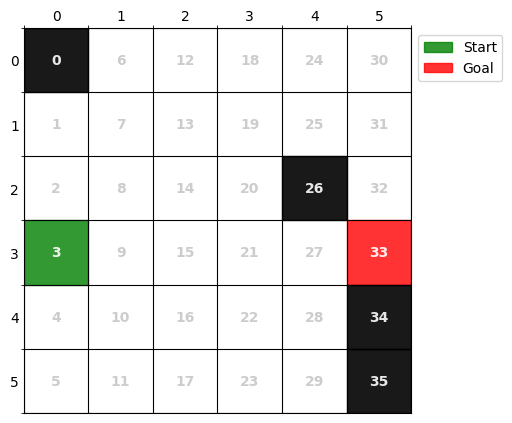

In [50]:
draw_maze(sample_maze)

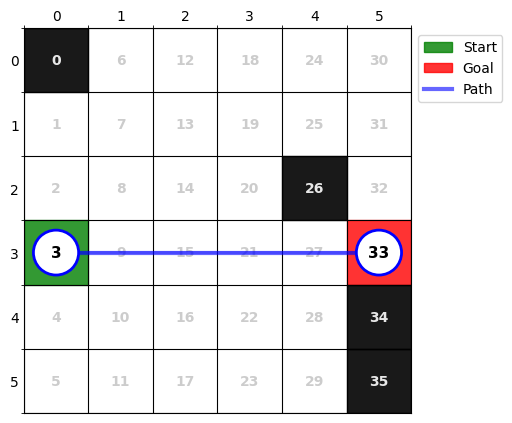

In [51]:
draw_maze(sample_maze, [sample_maze['start'],sample_maze['goal']])

In [52]:
def get_neighbors(node_id, barriers):
    # Rule (b): Convert current ID to coordinates to find neighbors
    x, y = get_coords(node_id)
    neighbors = []

    # Check all 8 directions (Horizontal, Vertical, Diagonal)
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            if dx == 0 and dy == 0:
                continue

            nx, ny = x + dx, y + dy

            # Rule (c): Stay within 6x6 grid and avoid barriers
            if 0 <= nx < 6 and 0 <= ny < 6:
                # Convert back to ID: ID = x*6 + y (based on your //6 and %6 logic)
                neighbor_id = nx * 6 + ny
                if neighbor_id not in barriers:
                    neighbors.append(neighbor_id)

    # Rule (a): Process neighbors in increasing order of ID
    neighbors.sort()
    return neighbors

In [53]:
sample_maze['barriers']

[0, 35, 34, 26]

In [71]:
get_neighbors(19, sample_maze['barriers'])

[12, 13, 14, 18, 20, 24, 25]

In [72]:
def depth_limited_search(current_coords, goal_coords, barriers, depth_limit, total_visited, current_path):
    # Convert coordinates to IDs for processing and path tracking
    current_id = get_node(current_coords)
    goal_id = get_node(goal_coords)

    # Rule: Track every node visited for time complexity analysis
    total_visited.append(current_id)

    # Success: Goal reached
    if current_id == goal_id:
        return True, current_path + [current_id], total_visited

    # Failure: Depth limit reached
    if depth_limit <= 0:
        return False, None, total_visited

    # get_neighbors returns IDs sorted in increasing order
    for neighbor_id in get_neighbors(current_id, barriers):
        if neighbor_id not in current_path:
            # FIX: We must unpack THREE values here to match the function signature
            found, result_path, total_visited = depth_limited_search(
                get_coords(neighbor_id),
                goal_coords,
                barriers,
                depth_limit - 1,
                total_visited,
                current_path + [current_id]
            )

            if found:
                return True, result_path, total_visited

    return False, None, total_visited

In [75]:
# Assuming 'a' is your maze_nodes dictionary
result_found, final_path, visited_nodes = depth_limited_search(
    sample_maze['start'],      # node_xy (Current start point)
    sample_maze['goal'],       # goal_xy
    sample_maze['barriers'],   # list of barrier IDs
    5,               # depth_limit (how many steps it's allowed to take)
    [],              # visited (starts as an empty list to track all explored nodes)
    []               # path (starts as an empty list to track the successful route)
)

In [76]:
print(final_path, result_found, visited_nodes)

[3, 8, 13, 20, 27, 33] True [3, 2, 1, 6, 7, 8, 12, 13, 14, 12, 7, 13, 18, 19, 13, 7, 8, 12, 14, 18, 19, 20, 7, 6, 12, 13, 8, 9, 13, 14, 15, 12, 6, 13, 18, 19, 13, 6, 8, 12, 14, 18, 19, 20, 14, 8, 9, 13, 15, 19, 20, 21, 8, 7, 6, 12, 13, 14, 9, 4, 10, 14, 15, 16, 13, 6, 7, 12, 14, 18, 19, 20, 14, 7, 9, 13, 15, 19, 20, 21, 15, 9, 10, 14, 16, 20, 21, 22, 7, 1, 6, 12, 13, 8, 9, 13, 14, 15, 6, 1, 8, 12, 13, 18, 19, 13, 8, 12, 14, 18, 19, 20, 8, 1, 6, 9, 4, 10, 14, 15, 16, 13, 6, 12, 14, 18, 19, 20, 14, 9, 13, 15, 19, 20, 21, 15, 9, 10, 14, 16, 20, 21, 22, 12, 6, 1, 13, 13, 6, 8, 14, 18, 19, 20, 18, 13, 19, 24, 25, 19, 13, 14, 18, 20, 24, 25, 13, 6, 1, 12, 8, 1, 9, 14, 15, 12, 6, 18, 19, 14, 8, 9, 15, 19, 20, 21, 18, 12, 19, 24, 25, 19, 12, 14, 18, 20, 24, 25, 20, 14, 15, 19, 21, 25, 27, 14, 8, 1, 9, 13, 15, 9, 4, 8, 10, 15, 16, 13, 6, 8, 12, 18, 19, 20, 15, 8, 9, 10, 16, 20, 21, 22, 19, 12, 13, 18, 20, 24, 25, 20, 13, 15, 19, 21, 25, 27, 21, 15, 16, 20, 22, 27, 28, 8, 1, 6, 7, 12, 13, 7, 6, 

In [77]:
sample_maze['barriers']

[0, 35, 34, 26]

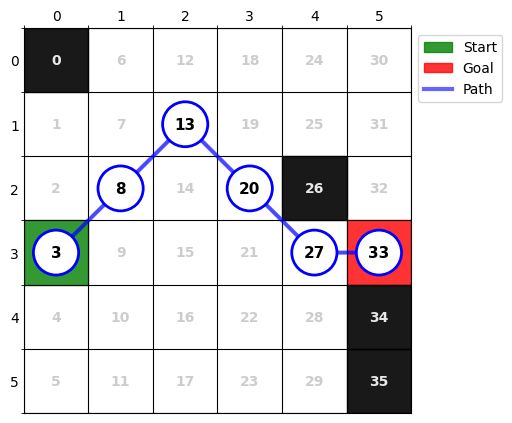

In [78]:
draw_maze(sample_maze, final_path)

In [59]:
def run_iddfs(maze_data):
    start_node = maze_data['start']
    goal_node = maze_data['goal']
    barriers = maze_data['barriers']

    all_explored_nodes = [] # Tracks every node touched across all iterations
    final_solution = None

    # Gradually increase depth from 0 to 36 (total cells in 6x6 grid)
    for depth in range(36):
        # We track nodes visited *specifically* at this depth level
        nodes_visited_at_this_depth = []

        # Start the search with an empty current_path []
        found, path, visited_nodes = depth_limited_search(
            start_node,
            goal_node,
            barriers,
            depth,
            nodes_visited_at_this_depth,
            []
        )

        # Add the work done in this iteration to our master log
        all_explored_nodes.extend(nodes_visited_at_this_depth)

        if found:
            final_solution = path
            print(f"Goal found at depth: {depth}")
            break # Stop searching once we find the shortest path

    return all_explored_nodes, final_solution

In [60]:
all_nodes, iddfs_solution = run_iddfs(sample_maze)
print(iddfs_solution)

Goal found at depth: 5
[3, 8, 13, 20, 27, 33]


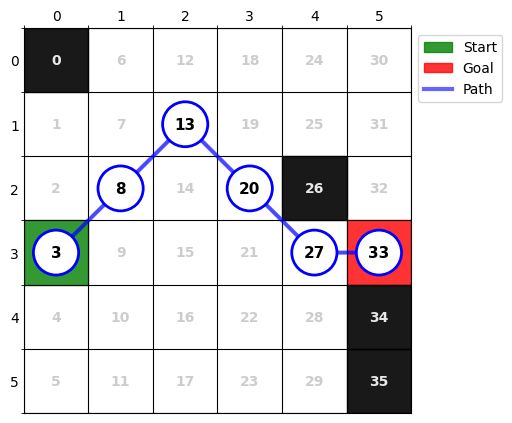

In [61]:
draw_maze(sample_maze, iddfs_solution)

In [79]:
def calculate_path_cost(path):
    cost = 0
    for i in range(len(path) - 1):
        c1 = get_coords(path[i])
        c2 = get_coords(path[i+1])
        # Rule (e): Euclidean distance
        cost += np.sqrt((c1[0]-c2[0])**2 + (c1[1]-c2[1])**2)
    return cost

# Test Run

In [89]:
maze = setup_maze()

Goal found at depth: 4


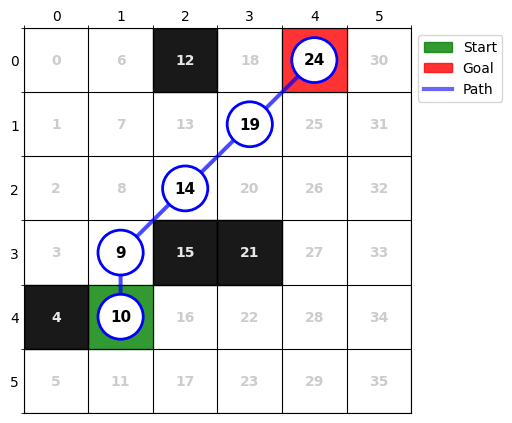

Total Time (Nodes Explored): 323 minutes
Final Path (IDs): [10, 9, 14, 19, 24]
Total Edge Cost: 5.24


In [90]:
visited, iddls_final_path = run_iddfs(maze)

draw_maze(maze,iddls_final_path)

print(f"Total Time (Nodes Explored): {len(visited)} minutes")
print(f"Final Path (IDs): {iddls_final_path}")
print(f"Total Edge Cost: {calculate_path_cost(iddls_final_path):.2f}")

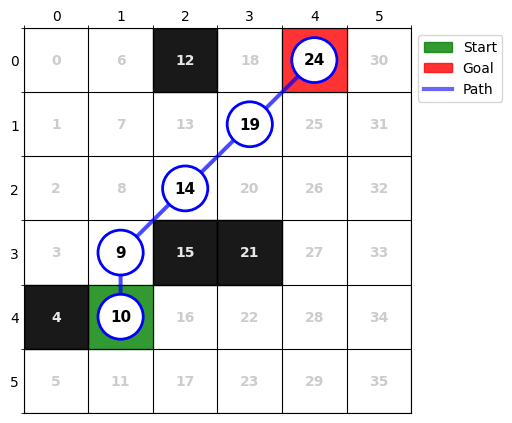

Total Time (Nodes Explored): 187 minutes
Final Path (IDs): [10, 3, 8, 13, 18, 24]
Total Edge Cost: 6.66


In [91]:
dls_result_found, dls_final_path, visited_nodes = depth_limited_search(
    maze['start'],
    maze['goal'],
    maze['barriers'],
    5,
    [],
    []
)

draw_maze(maze,iddls_final_path)

print(f"Total Time (Nodes Explored): {len(visited_nodes)} minutes")
print(f"Final Path (IDs): {dls_final_path}")
print(f"Total Edge Cost: {calculate_path_cost(dls_final_path):.2f}")